<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Silhouette Score: 0.5547

Customer Segments:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35                  19

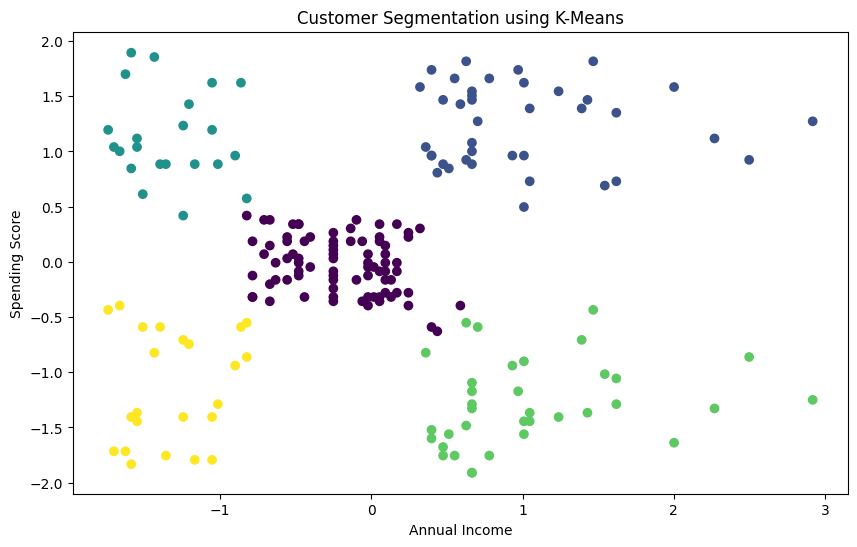

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Customer Segmentation Dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Create clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster to dataset
df["Cluster"] = clusters

# Silhouette Score
score = silhouette_score(
    X_scaled,
    clusters
)

print("K-Means Silhouette Score:",
      round(score, 4))

# Display customer clusters
print("\nCustomer Segments:")
print(
    df[
        [
            "CustomerID",
            "Gender",
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)",
            "Cluster"
        ]
    ].head(20)
)

# Graph
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title(
    "Customer Segmentation using K-Means"
)

plt.show()

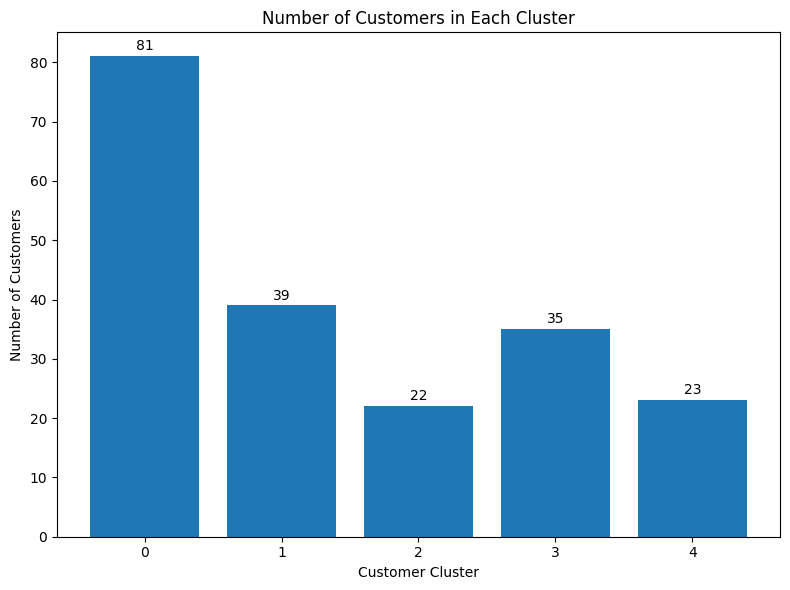

In [8]:
# ============================================
# GRAPH 2 - NUMBER OF CUSTOMERS IN EACH CLUSTER
# ============================================

cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

for i, value in enumerate(cluster_counts.values):
    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

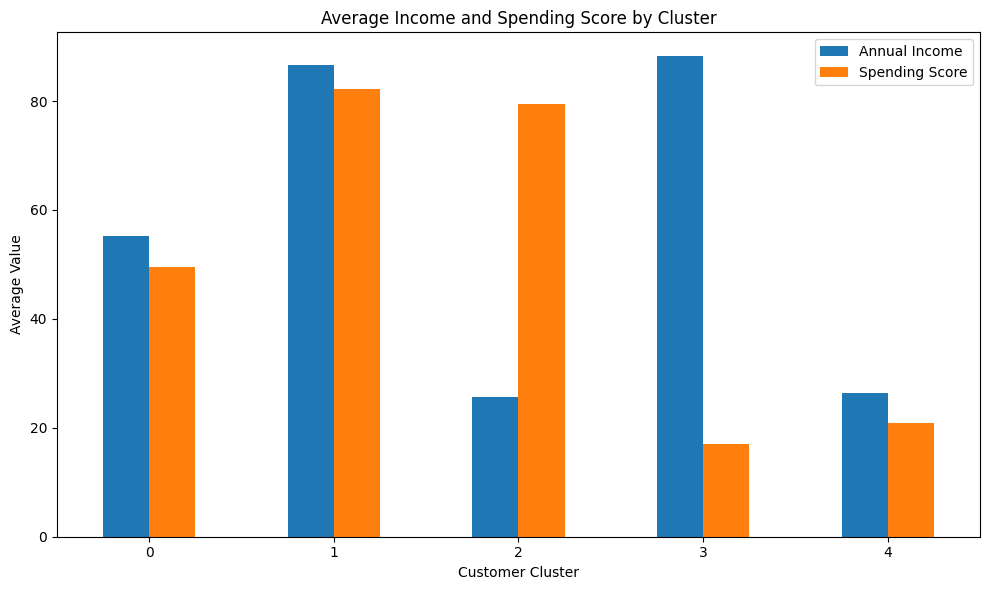

In [9]:
# ============================================
# GRAPH 3 - AVERAGE INCOME & SPENDING SCORE
# ============================================

cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Value")
plt.title("Average Income and Spending Score by Cluster")

plt.xticks(rotation=0)
plt.legend(
    ["Annual Income", "Spending Score"]
)

plt.tight_layout()
plt.show()